In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from tqdm.notebook import tqdm
from scipy.stats import sem
from my_utils import *

from pathlib import Path
import sys
import warnings

In [2]:
modelpath = Path('../model')
sys.path.append(str(modelpath))
import config.config as config

In [3]:
arg = config.ConfigNoise()
arg.device = 'cpu'
arg.obs_noise_range = [0, 0.6]

## Choose agents

In [4]:
from Actor3 import Actor as Actor3; from Critic5 import Critic as Critic5

progress_agents_path = Path.cwd().parents[1] / 'agents'
agent_archs = ['Actor3Critic5_noise_pro', 'Actor3Critic5_noise_obs','Actor3Critic5_noise', 'EKF_noise']
MAX_TRAINING_T = 1e5

In [5]:
def select_agents(progress_agents_path, agent_archs, MAX_TRAINING_T):  
    seeds = [[''.join(filter(str.isdigit, file.stem.split('_')[1]))
              for file in (Path.cwd().parent / 'model' / 'training_curve' / agent_arch.split('_', 1)[1]
                          ).glob(f'{agent_arch.split("_", 1)[0]}*.*')] 
             for agent_arch in agent_archs]
    
    agent_paths = []; agent_files = []
    for agent_arch, seeds_ in zip(agent_archs, seeds): # loop each agent
        agent_path = []; agent_file = []
        for seed in seeds_:
            perform_file_path = Path.cwd().parent / 'model' / 'training_curve' / agent_arch.split('_', 1)[1]
            perform_file_path /= f'{agent_arch.split("_", 1)[0]}_seed{seed}.csv'
            perform_file = pd.read_csv(perform_file_path)
            perform_file = perform_file[(perform_file.episode > 0) & (perform_file.episode < MAX_TRAINING_T)]
            best_episode = perform_file.episode.unique()[np.sum([perform_file[perform_file.task == task].reward_rate 
                                      for task in perform_file.task.unique()], axis=0).argmax()]
            
            agent_path.append(progress_agents_path / agent_arch.replace('_', '/', 1) / f'seed{seed}')
            agent_file.append(list(agent_path[-1].glob(f'*-{best_episode}.*'))[0].stem.split('.')[0])
        agent_paths.append(agent_path); agent_files.append(agent_file)
    
    
    return agent_paths, agent_files

In [6]:
agent_paths, agent_files = select_agents(progress_agents_path, agent_archs, MAX_TRAINING_T)

## Run LSTM agents

In [7]:
from Agent_LSTM import *
from Environment import Env

In [8]:
def LSTM_agent_simulation(agent, target_positions, obs_noise_stds):
    reset_seeds(arg.SEED_NUMBER)
    env = Env(arg)

    pos_x = []; pos_x_end = []; pos_y = []; pos_y_end = []
    head_dir = []; head_dir_end = []; pos_r = []; pos_theta = []; pos_r_end = []; pos_theta_end = []; 
    pos_v = []; pos_w = []
    target_x = []; target_y = []; target_r = []; target_theta = []
    rewarded = []; relative_radius = []; relative_angle = []
    action_v = []; action_w = []
    relative_radius_end = []; relative_angle_end = []
    obs_v = []; obs_w = []; steps = []
    state_ = []; action_ = []

    for target_position, obs_noise_std in tqdm(zip(target_positions, obs_noise_stds)):
        cross_start_threshold = False
        x = env.reset(target_position=target_position)
        agent.bstep.reset(env.pro_gains, obs_noise_std=obs_noise_std)
        last_action = torch.zeros([1, 1, arg.ACTION_DIM])
        last_action_raw = last_action.clone()

        state = torch.cat([x[-arg.OBS_DIM:].view(1, 1, -1), last_action,
                           env.target_position_obs.view(1, 1, -1)], dim=2).to(arg.device)

        hidden_in = None

        true_states = []
        actions = []
        states = []
        observations = []
        
        for t in range(arg.EPISODE_LEN):
            if not cross_start_threshold and (last_action_raw.abs() > arg.TERMINAL_ACTION).any():
                cross_start_threshold = True
                
            action, action_raw, hidden_out = agent.select_action(state, hidden_in, action_noise=None)
            next_x, reached_target, _ = env(x, action, t)
            next_ox = agent.bstep(next_x)
            next_state = torch.cat([next_ox.view(1, 1, -1), action,
                                    env.target_position_obs.view(1, 1, -1)], dim=2).to(arg.device)

            is_stop = env.is_stop(x, action)

            true_states.append(x)
            states.append(state)
            actions.append(action)
            observations.append(next_ox)
            
            last_action_raw = action_raw
            state = next_state
            x = next_x
            hidden_in = hidden_out

            if is_stop and cross_start_threshold:
                break

        # Trial end
        pos_x_temp, pos_y_temp, head_dir_temp, pos_v_temp, pos_w_temp \
                    = torch.chunk(torch.cat(true_states, dim=1), x.shape[0], dim=0)
        pos_x.append(pos_x_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_y.append(pos_y_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_x_end.append(pos_x[-1][-1])
        pos_y_end.append(pos_y[-1][-1])
        head_dir.append(np.rad2deg(head_dir_temp.view(-1).numpy()))
        pos_v.append(pos_v_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_w.append(np.rad2deg(pos_w_temp.view(-1).numpy()))
        head_dir_end.append(head_dir[-1][-1])

        rho, phi = cart2pol(pos_x[-1], pos_y[-1])
        pos_r.append(rho)
        pos_theta.append(np.rad2deg(phi))
        pos_r_end.append(rho[-1])
        pos_theta_end.append(np.rad2deg(phi[-1]))

        target_x.append(target_position[0].item() * arg.LINEAR_SCALE)
        target_y.append(target_position[1].item() * arg.LINEAR_SCALE)
        tar_rho, tar_phi = cart2pol(target_x[-1], target_y[-1])
        target_r.append(tar_rho)
        target_theta.append(np.rad2deg(tar_phi))
        
        state_.append(torch.cat(states))
        
        action_.append(torch.cat(actions))
        action_v_temp, action_w_temp = torch.chunk(torch.cat(actions).squeeze(1), 
                                                   action.shape[-1], dim=1)
        action_v.append(action_v_temp.view(-1).numpy())
        action_w.append(action_w_temp.view(-1).numpy())
        
        obs_v_temp, obs_w_temp = torch.chunk(torch.cat(observations, dim=1), 
                                             next_ox.shape[0], dim=0)
        obs_v.append(obs_v_temp.view(-1).numpy())
        obs_w.append(obs_w_temp.view(-1).numpy())
        

        relative_r, relative_ang = get_relative_r_ang(pos_x[-1], pos_y[-1], head_dir[-1], 
                                                      target_x[-1], target_y[-1])
        relative_radius.append(relative_r)
        relative_angle.append(np.rad2deg(relative_ang))
        relative_radius_end.append(relative_r[-1])
        relative_angle_end.append(np.rad2deg(relative_ang[-1]))
        rewarded.append((reached_target & is_stop).item())
        
        steps.append(np.arange(relative_r.size))

    return(pd.DataFrame().assign(pos_x=pos_x, pos_y=pos_y, pos_x_end=pos_x_end, pos_y_end=pos_y_end,
                                 head_dir=head_dir, head_dir_end=head_dir_end, 
                                 pos_r=pos_r, pos_theta=pos_theta, 
                                 pos_r_end=pos_r_end, pos_theta_end=pos_theta_end, pos_v=pos_v, 
                                 pos_w=pos_w, target_x=target_x, target_y=target_y, 
                                 target_r=target_r,
                                 target_theta=target_theta, rewarded=rewarded,
                                 relative_radius=relative_radius, relative_angle=relative_angle,
                                 action_v=action_v, action_w=action_w, 
                                 relative_radius_end=relative_radius_end,
                                 relative_angle_end=relative_angle_end,
                                 obs_v=obs_v, obs_w=obs_w, steps=steps,
                                 obs_noise_std=obs_noise_stds,
                                 state=state_, action=action_))

In [9]:
modular_pro_idx = 0
modular_pro_agents = []
for agent_path, agent_file in zip(agent_paths[modular_pro_idx], agent_files[modular_pro_idx]):
    agent_ = Agent(arg, Actor3, Critic5)
    agent_.data_path = agent_path
    agent_.load(agent_file, load_memory=False, load_optimzer=False)
    modular_pro_agents.append(agent_)
    
modular_obs_idx = 1
modular_obs_agents = []
for agent_path, agent_file in zip(agent_paths[modular_obs_idx], agent_files[modular_obs_idx]):
    agent_ = Agent(arg, Actor3, Critic5)
    agent_.data_path = agent_path
    agent_.load(agent_file, load_memory=False, load_optimzer=False)
    modular_obs_agents.append(agent_)
    
modular_both_idx = 2
modular_both_agents = []
for agent_path, agent_file in zip(agent_paths[modular_both_idx], agent_files[modular_both_idx]):
    agent_ = Agent(arg, Actor3, Critic5)
    agent_.data_path = agent_path
    agent_.load(agent_file, load_memory=False, load_optimzer=False)
    modular_both_agents.append(agent_)

In [10]:
SAMPLE_SIZE = 2000

reset_seeds(0)
env = Env(arg)
target_positions = []
for _ in range(SAMPLE_SIZE):
    __ = env.reset()
    target_positions.append(env.target_position)

In [11]:
mo_pro_trajectories = []; mo_obs_trajectories = []; mo_both_trajectories = []
for obs_noise_stds in np.linspace(*arg.obs_noise_range, 7):
    obs_noise_stds = [obs_noise_stds * arg.process_gain_default] * SAMPLE_SIZE
        
    mo_pro_trajectories.append([LSTM_agent_simulation(agent, target_positions, obs_noise_stds) 
                                for agent in modular_pro_agents])
    mo_obs_trajectories.append([LSTM_agent_simulation(agent, target_positions, obs_noise_stds) 
                                for agent in modular_obs_agents])
    mo_both_trajectories.append([LSTM_agent_simulation(agent, target_positions, obs_noise_stds) 
                                for agent in modular_both_agents])

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

## Run EKF agent

In [12]:
from Agent_EKF import *

In [13]:
def EKF_agent_simulation(agent, target_positions, obs_noise_stds):
    reset_seeds(0)
    env = Env(arg)
    agent.bstep.obs_noise_range = arg.obs_noise_range
    
    pos_x = []; pos_x_end = []; pos_y = []; pos_y_end = []
    head_dir = []; head_dir_end = []; pos_r = []; pos_theta = []; pos_r_end = []; pos_theta_end = []; 
    pos_v = []; pos_w = []
    target_x = []; target_y = []; target_r = []; target_theta = []
    rewarded = []; relative_radius = []; relative_angle = []
    action_v = []; action_w = []
    relative_radius_end = []; relative_angle_end = []
    EKF_belief_mean = []; EKF_belief_std = []
    obs_v = []; obs_w = []
    steps = []; state_ = []; action_ = []

    for target_position, obs_noise_std in tqdm(zip(target_positions, obs_noise_stds)):
        cross_start_threshold = False
        x = env.reset(target_position=target_position)
        b, state = agent.bstep.reset(env.pro_gains, env.pro_noise_std, env.target_position, 
                                     obs_noise_std=obs_noise_std)
        state = state.to(arg.device)
        last_action_raw = torch.zeros(1, arg.ACTION_DIM)

        true_states = []
        actions = []
        states = []
        observations = []
        EKFb_mus = []
        EKFb_stds = []
        
        for t in range(arg.EPISODE_LEN):
            if not cross_start_threshold and (last_action_raw.abs() > arg.TERMINAL_ACTION).any():
                cross_start_threshold = True
                
            action, action_raw = agent.select_action(state, action_noise=None)
            next_x, reached_target, _ = env(x, action, t)
            next_ox = agent.bstep.observation(next_x)
            next_b = agent.bstep(b, next_ox, action, env.perturbation_vt, env.perturbation_wt)
            next_state = agent.bstep.b_reshape(next_b).to(arg.device)
            
            is_stop = env.is_stop(x, action)
            
            true_states.append(x)
            states.append(state)
            actions.append(action)
            observations.append(next_ox)
            
            EKFb_mus.append(b[0])
            EKFb_stds.append(torch.cat([torch.diag(b[1]), b[1][0, 1:3], b[1][1, 2:3]]))

            last_action_raw = action_raw
            state = next_state
            x = next_x
            b = next_b

            if is_stop and cross_start_threshold:
                break

        # Trial end
        pos_x_temp, pos_y_temp, head_dir_temp, pos_v_temp, pos_w_temp \
                    = torch.chunk(torch.cat(true_states, dim=1), x.shape[0], dim=0)
        pos_x.append(pos_x_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_y.append(pos_y_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_x_end.append(pos_x[-1][-1])
        pos_y_end.append(pos_y[-1][-1])
        head_dir.append(np.rad2deg(head_dir_temp.view(-1).numpy()))
        pos_v.append(pos_v_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_w.append(np.rad2deg(pos_w_temp.view(-1).numpy()))
        head_dir_end.append(head_dir[-1][-1])

        rho, phi = cart2pol(pos_x[-1], pos_y[-1])
        pos_r.append(rho)
        pos_theta.append(np.rad2deg(phi))
        pos_r_end.append(rho[-1])
        pos_theta_end.append(np.rad2deg(phi[-1]))

        target_x.append(target_position[0].item() * arg.LINEAR_SCALE)
        target_y.append(target_position[1].item() * arg.LINEAR_SCALE)
        tar_rho, tar_phi = cart2pol(target_x[-1], target_y[-1])
        target_r.append(tar_rho)
        target_theta.append(np.rad2deg(tar_phi))
        
        state_.append(torch.cat(states))

        action_.append(torch.cat(actions))
        action_v_temp, action_w_temp = torch.chunk(torch.cat(actions), action.shape[-1], dim=1)
        action_v.append(action_v_temp.view(-1).numpy())
        action_w.append(action_w_temp.view(-1).numpy())
        
        obs_v_temp, obs_w_temp = torch.chunk(torch.cat(observations, dim=1), 
                                             next_ox.shape[0], dim=0)
        obs_v.append(obs_v_temp.view(-1))
        obs_w.append(obs_w_temp.view(-1))

        relative_r, relative_ang = get_relative_r_ang(pos_x[-1], pos_y[-1], head_dir[-1], 
                                                      target_x[-1], target_y[-1])
        relative_radius.append(relative_r)
        relative_angle.append(np.rad2deg(relative_ang))
        relative_radius_end.append(relative_r[-1])
        relative_angle_end.append(np.rad2deg(relative_ang[-1]))
        rewarded.append((reached_target & is_stop).item())
        
        EKF_belief_mean.append(torch.cat(EKFb_mus, dim=1).T.numpy())
        EKF_belief_std.append(torch.stack(EKFb_stds, dim=0).numpy())
        steps.append(np.arange(relative_r.size))

    return(pd.DataFrame().assign(pos_x=pos_x, pos_y=pos_y, pos_x_end=pos_x_end, pos_y_end=pos_y_end,
                                 head_dir=head_dir, head_dir_end=head_dir_end, 
                                 pos_r=pos_r, pos_theta=pos_theta, 
                                 pos_r_end=pos_r_end, pos_theta_end=pos_theta_end, pos_v=pos_v, 
                                 pos_w=pos_w, target_x=target_x, target_y=target_y, 
                                 target_r=target_r,
                                 target_theta=target_theta, rewarded=rewarded,
                                 relative_radius=relative_radius, relative_angle=relative_angle,
                                 action_v=action_v, action_w=action_w, 
                                 relative_radius_end=relative_radius_end,
                                 relative_angle_end=relative_angle_end,
                                 EKF_belief_mean=EKF_belief_mean,
                                 EKF_belief_std=EKF_belief_std,
                                 obs_v=obs_v, obs_w=obs_w, steps=steps,
                                 obs_noise_std=obs_noise_stds,
                                 state=state_, action=action_))

In [14]:
EKF_idx = 3
EKF_agents = []
for agent_path, agent_file in zip(agent_paths[EKF_idx], agent_files[EKF_idx]):
    agent_ = Agent(arg)
    agent_.data_path = agent_path
    agent_.load(agent_file, load_memory=False, load_optimzer=False)
    EKF_agents.append(agent_)

In [15]:
EKF_trajectories = []
for obs_noise_stds in np.linspace(*arg.obs_noise_range, 7):
    obs_noise_stds = [obs_noise_stds * arg.process_gain_default] * SAMPLE_SIZE
        
    EKF_trajectories.append([EKF_agent_simulation(agent, target_positions, obs_noise_stds) for agent in EKF_agents])

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

# Figures

In [16]:
locals().update(config_colors())
major_formatter = FuncFormatter(my_tickformatter)

fontsize = 7
lw = 1

## b

In [17]:
mo_pro_errors = np.vstack([[df.relative_radius_end.mean() for df in dfs] for dfs in mo_pro_trajectories])
mo_obs_errors = np.vstack([[df.relative_radius_end.mean() for df in dfs] for dfs in mo_obs_trajectories])
mo_both_errors = np.vstack([[df.relative_radius_end.mean() for df in dfs] for dfs in mo_both_trajectories])
EKF_errors = np.vstack([[df.relative_radius_end.mean() for df in dfs] for dfs in EKF_trajectories])

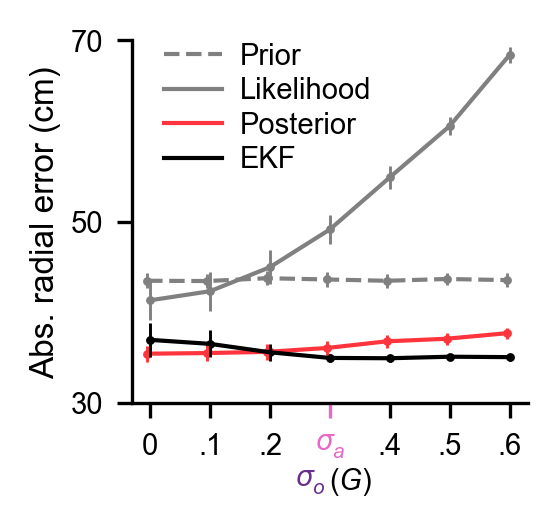

In [18]:
width = 1.7; height = 1.6
marker = 'o'; marker_size = 2; marker_lw = lw * 0.7

xticks = np.delete(np.around(np.linspace(*arg.obs_noise_range, 7), 1), 3)
yticks = [30, 50, 70]

colors = ['gray', 'gray', belief_c, EKF_c]
labels = ['Prior', 'Likelihood', 'Posterior', 'EKF']
errors_all = [mo_pro_errors, mo_obs_errors, mo_both_errors, EKF_errors]
    
with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(1, 1, 1)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.xticks(xticks, fontsize=fontsize)
    ax.set_xticks([0.3], ['$\sigma_a$'], minor=True, fontsize=fontsize, c=motor_c)
    ax.tick_params(axis='x', which='minor', color=motor_c, length=3.5, width=0.8)
    plt.yticks(yticks, fontsize=fontsize)
    ax.set_xlabel('$\sigma_o$', fontsize=fontsize, color=sensory_c)
    ax.set_ylabel(r'Abs. radial error (cm)', fontsize=fontsize + 1)
    ax.set_xlim(xticks[0]-0.03, xticks[-1] + 0.03)
    ax.set_ylim(yticks[0], yticks[-1])
    ax.xaxis.set_label_coords(0.45, -0.18)
    ax.yaxis.set_label_coords(-0.18, 0.5)
    ax.xaxis.set_major_formatter(major_formatter)
    ax.yaxis.set_major_formatter(major_formatter)

    xshifts = [-0.005, 0.005, -0.005, 0.005]   
    xdata = np.around(np.linspace(*arg.obs_noise_range, 7), 1)
    for agent_idx, errors in enumerate(errors_all):
        ls = '--' if agent_idx == 0 else '-'
        xdata = xdata + xshifts[agent_idx]
        ymean = np.mean(errors, axis=1)
        yerror = sem(errors, axis=1)
        ax.scatter(xdata, ymean, c=colors[agent_idx], s=marker_size, lw=marker_lw, marker=marker, clip_on=False)
        ax.plot(xdata, ymean, c=colors[agent_idx], lw=lw, label=labels[agent_idx], ls=ls, clip_on=False)
        ax.errorbar(xdata, ymean, yerror, c=colors[agent_idx], lw=lw * 0.7, ls='none') 
        
    ax.legend(fontsize=fontsize, frameon=False, loc=[0.05, 0.6], 
              handletextpad=0.6, labelspacing=0.22, ncol=1, columnspacing=0.5)
    ax.text(0.298, 20.5, '$(G)$', fontsize=fontsize)
    
    fig.tight_layout(pad=0.15, rect=(0, 0, 1, 1))

    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure7/raw/{name}.pdf'.format(
    #    name='sup_agent_error'), orientation='portrait', format='pdf', transparent=True)    